In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import kpss
from statsmodels.tools.eval_measures import rmse
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from concurrent.futures import ThreadPoolExecutor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('../dataset/preprocessed_dataset.csv')

# Convert to datetime
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

# Convert to epoch time in seconds
df['date'] = df['date'].astype(int) // 10**9 

# Set Date as index
df.set_index('date', inplace=True)

df.head()

# Group by Date and aggregate (e.g., sum for Weekly_Sales)
df = df.groupby('date').agg({
    'is_holiday': 'max',
    'temperature': 'mean',
    'fuel_price': 'mean',
    'cpi': 'mean',
    'unemployment': 'mean',
    'fed_funds': 'mean',
    'ics': 'mean',
    'weekly_sales': 'mean',
}).reset_index()

df.head()

,date,is_holiday,temperature,fuel_price,cpi,unemployment,fed_funds,ics,weekly_sales
0,1265328000,0,34.037333,2.717844,167.730885,8.619311,0.13,73.6,151.995985
1,1265932800,1,34.151333,2.694022,167.825608,8.619311,0.13,73.6,151.133305
2,1266537600,0,37.719778,2.672067,167.871686,8.619311,0.13,73.6,150.922807
3,1267142400,0,39.243556,2.683933,167.909657,8.619311,0.13,73.6,147.348368
4,1267747200,0,42.917333,2.731200,167.947628,8.619311,0.16,73.6,149.925182


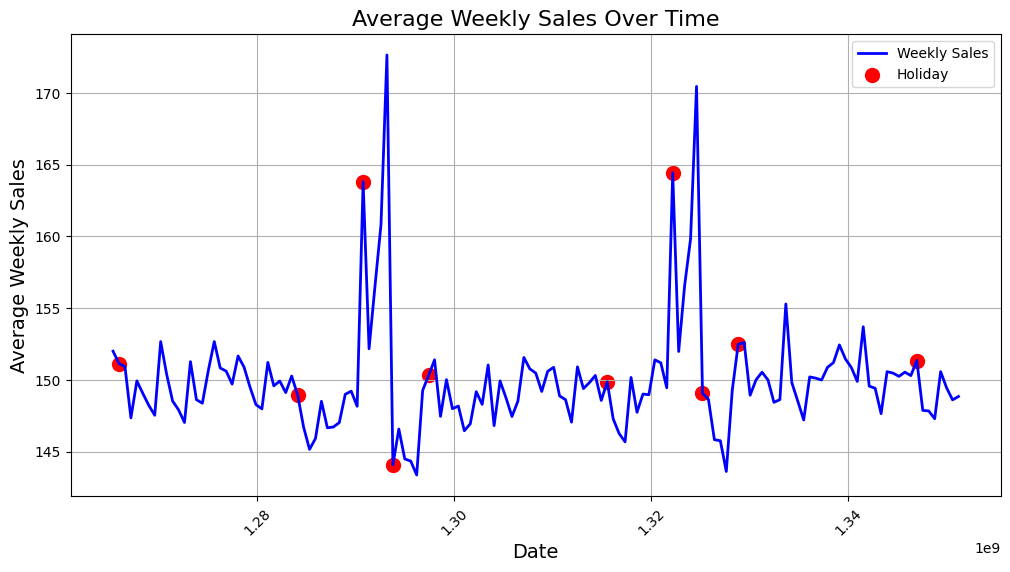

In [5]:
# Plot Weekly Sales over Time
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['weekly_sales'], color='blue', linewidth=2, label='Weekly Sales')

# Highlight Holidays
holiday_dates = df[df['is_holiday'] == 1]  # Filter rows where Holiday_Flag is 1
plt.scatter(holiday_dates['date'], holiday_dates['weekly_sales'], color='red', marker='o', s=100, label='Holiday')

# Add titles and labels
plt.title('Average Weekly Sales Over Time', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Average Weekly Sales', fontsize=14)
plt.grid(True)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show legend
plt.legend()

# Show the plot
plt.show()

In [6]:
# ADF Test
result_test = adfuller(df['weekly_sales'])

print(f"ADF Statistic: {result_test[0]}")
print(f"P-value: {result_test[1]}")
print(f"Critical Values: {result_test[4]}")

if result_test[1] < 0.05:
    print("Reject H0: Data is stationary")
else:
    print("Fail to reject H0: Data is non-stationary")

ADF Statistic: -6.194965232382745
P-value: 5.996195411801252e-08
Critical Values: {'1%': np.float64(-3.47864788917503), '5%': np.float64(-2.882721765644168), '10%': np.float64(-2.578065326612056)}
Reject H0: Data is stationary


In [7]:
scaler = StandardScaler()
exog_features = ["temperature", "fuel_price", "cpi", "unemployment", "fed_funds", "ics"]

df[exog_features] = scaler.fit_transform(df[exog_features])
df.head()

,date,is_holiday,temperature,fuel_price,cpi,unemployment,fed_funds,ics,weekly_sales
0,1265328000,0,-1.761050,-1.497470,-1.245435,1.286216,-0.190588,0.391824,151.995985
1,1265932800,1,-1.753510,-1.553143,-1.214773,1.286216,-0.190588,0.391824,151.133305
2,1266537600,0,-1.517496,-1.604453,-1.199858,1.286216,-0.190588,0.391824,150.922807
3,1267142400,0,-1.416715,-1.576721,-1.187567,1.286216,-0.190588,0.391824,147.348368
4,1267747200,0,-1.173734,-1.466258,-1.175276,1.286216,0.502312,0.391824,149.925182


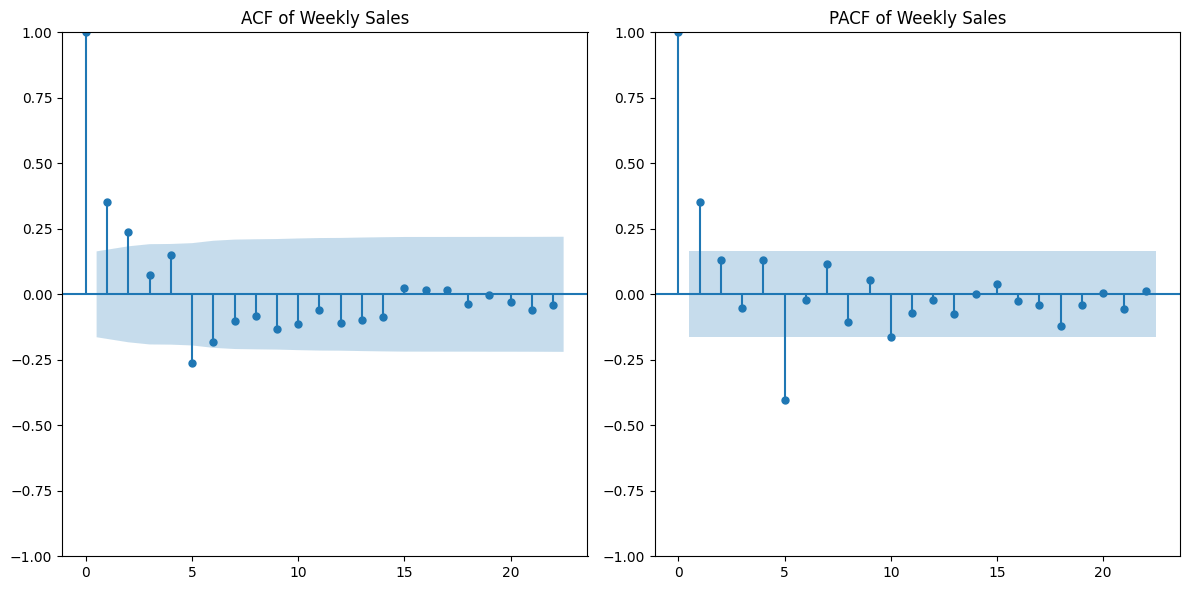

/home/dmtran30/anaconda3/envs/Demand-Forecast/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/dmtran30/anaconda3/envs/Demand-Forecast/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/dmtran30/anaconda3/envs/Demand-Forecast/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/dmtran30/anaconda3/envs/Demand-Forecast/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likeliho

Best Parameters: p=10, d=0, q=1 with AIC = 753.3341988362369
Mean Absolute Error (MAE): 2.1005357165941514
Mean Squared Error (MSE): 8.426009684255936
Root Mean Squared Error (RMSE): 2.902758977982143
R-squared (R²): 0.4711952980501172


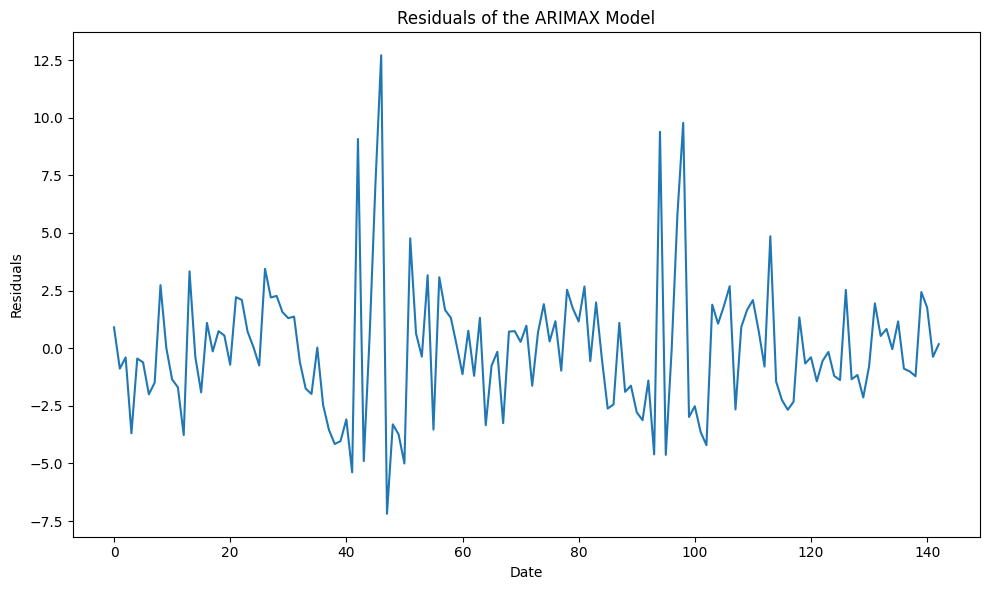

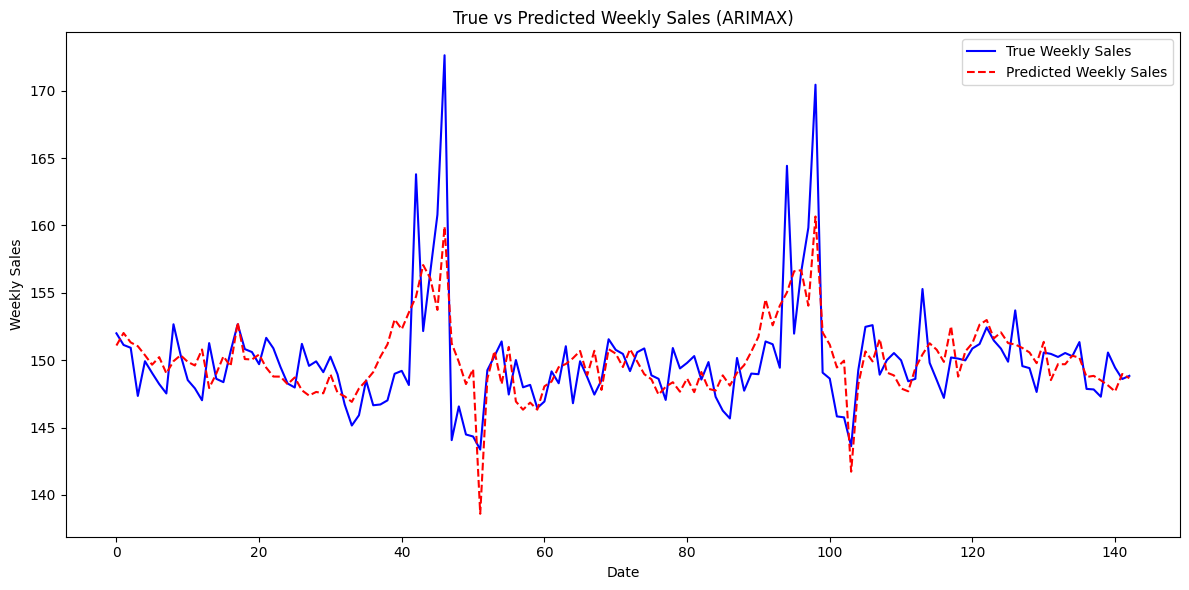

In [18]:
# Plot ACF and PACF for Weekly_Sales to determine p, d, q
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_acf(df['weekly_sales'], ax=axes[0], title="ACF of Weekly Sales")
plot_pacf(df['weekly_sales'], ax=axes[1], title="PACF of Weekly Sales")
plt.tight_layout()
plt.show()

# Define explanatory (X) and target (y) variables
X = df[['is_holiday', 'temperature', 'fuel_price', 'cpi', 'unemployment', 'fed_funds', 'ics']]
y = df['weekly_sales']

# Try different p, d, q combinations for ARIMAX
p_values = range(0, 11)  # AR terms
d_values = [0, 1]  # Differencing
q_values = range(0, 6)  # MA terms

# Function to fit the ARIMAX model
def fit_arimax(p, d, q):
    try:
        model = ARIMA(y, exog=X, order=(p, d, q))
        fitted_model = model.fit()
        return (p, d, q, fitted_model.aic, fitted_model)
    except Exception as e:
        return (p, d, q, np.inf, None)

# Set up the parameter grid
parameter_grid = [(p, d, q) for p in p_values for d in d_values for q in q_values]

# Parallelize grid search using ThreadPoolExecutor
with ThreadPoolExecutor(max_workers=8) as executor:  # Adjust max_workers as needed
    results = list(executor.map(lambda params: fit_arimax(*params), parameter_grid))

# Find the best parameters based on AIC
best_params = min(results, key=lambda x: x[3])
print(f"Best Parameters: p={best_params[0]}, d={best_params[1]}, q={best_params[2]} with AIC = {best_params[3]}")

# Extract the best model
best_model = best_params[4]

# If a valid model was found, generate predictions
if best_model is not None:
    # Make predictions with the best ARIMAX model
    y_true = y
    y_pred = best_model.predict(start=0, end=len(y)-1, exog=X)
    
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    # Display the metrics
    print(f"Mean Absolute Error (MAE): {mae}")
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"Root Mean Squared Error (RMSE): {rmse}")
    print(f"R-squared (R²): {r2}")

    # Optional: Plot residuals to check if they resemble white noise
    residuals = y_true - y_pred
    plt.figure(figsize=(10, 6))
    plt.plot(residuals)
    plt.title("Residuals of the ARIMAX Model")
    plt.xlabel("Date")
    plt.ylabel("Residuals")
    plt.tight_layout()
    plt.show()

    # Plot predicted vs. true Weekly Sales
    plt.figure(figsize=(12, 6))
    plt.plot(y, label="True Weekly Sales", color='blue')
    plt.plot(y_pred, label="Predicted Weekly Sales", color='red', linestyle='--')
    plt.legend()
    plt.title("True vs Predicted Weekly Sales (ARIMAX)")
    plt.xlabel("Date")
    plt.ylabel("Weekly Sales")
    plt.tight_layout()
    plt.show()
else:
    print("No valid model was found!")